# Day 027 · 复权处理 · 中国版
**Adjustments** · 阶段 P1 · 量化基础

> 你下载的茅台2001 年那个三十多块的开盘价,直接拿来做回测大概率算出来全是错的。原因就是复权处理这件事 — 公司每次送股、派现金分红,股价会在那一天突然下跳一截,这叫除权日跳变。如果不复权,你的均线策略会被这个跳点带歪,实盘那天会被假信号误触发卖出,几年下来累计错过太多回报。这一节我们讲清楚四件事:除权除息是什么(为什么股价那天会跳)、前复权是什么(把过去价格按今天单位换算,看趋势用)、后复权是什么(把今天价格按历史单位换算,算长期收益用)、复权因子怎么算(累乘所有除权日调整系数)。代码里我们用 Python 拉茅台从上市到今天的原始价,看清除权日跳变,然后手算复权因子还原成前复权和后复权,对比3 条曲线看真实回报的差距。这是从下载数据走向能用数据做策略的关键一步,直接决定你的回测能不能信。

---

### 关于「中国版」

本 notebook 是为**国内学员**优化的版本:
- 数据源用 **akshare**(国内可访问、零 VPN、免注册),取代了视频里的 yfinance
- 标的尽量保持原意:美股 ETF→A 股 ETF / 国际公司→A 股龙头
- 所讲的**概念和方法 100% 一致**,但**具体数字可能与视频里略有差异**(因为是不同时间窗 / 不同标的)
- 一般情况国内 `pip install akshare` 即可,无需 token / VPN

**课件生成日期:** 2026-05-23  ·  **建议学习时长:** 18 分钟

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有必需的 Python 包(含 `akshare`),缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续


In [1]:
# === 环境自检 + 自动安装(运行此单元格即可)===
import importlib, subprocess, sys, os

REQUIRED = ["akshare", "matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels"]
PIP_NAME = {"sklearn":"scikit-learn","cv2":"opencv-python","PIL":"Pillow","bs4":"beautifulsoup4","yaml":"PyYAML"}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))
if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置 ===
import matplotlib, matplotlib.pyplot as plt, matplotlib.font_manager as fm
CJK = ["/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
       "C:/Windows/Fonts/msyh.ttc","C:/Windows/Fonts/simhei.ttf",
       "/System/Library/Fonts/PingFang.ttc","/System/Library/Fonts/STHeiti Medium.ttc"]
for p in CJK:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP","Microsoft YaHei","PingFang SC","SimHei","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪


## 🔌 第二步:加载国内数据助手

下面这一格是**工具函数**(可以折叠,不需要修改)。它把 `yfinance` 风格的 ticker(如 `600519.SS`)自动路由到对应的 akshare 接口,提供 `get_close(ticker)` 和 `get_close_multi(tickers_dict)` 两个函数。

In [2]:
# === 国内数据源助手(akshare 后端,不需要 VPN)===
# 这一格是工具函数,可以折叠,不需要修改。
# 它把 yfinance 风格的 ticker(如 "600519.SS" / "0700.HK" / "AAPL" / "BTC-USD")
# 自动路由到对应的 akshare 接口,统一返回 yfinance 风格的 Close DataFrame。

import re
from datetime import datetime, timedelta
import pandas as pd
import akshare as ak

_TICKER_MAP = {
    "^GSPC": ("us_index_sina", ".INX"),
    "^DJI":  ("us_index_sina", ".DJI"),
    "^IXIC": ("us_index_sina", ".IXIC"),
    "GC=F":  ("foreign_futures", "GC"),
    "SI=F":  ("foreign_futures", "SI"),
    "CL=F":  ("foreign_futures", "CL"),
    "BTC-USD": ("crypto", "BTC"),
    "ETH-USD": ("crypto", "ETH"),
}

def _retry(fn, *args, _retries=4, _wait=1.5, **kwargs):
    """akshare 上游(东方财富/新浪/Binance)偶有 RemoteDisconnected / Timeout,自动重试 4 次。
    2026-05-11 加:用户跑 cn notebook 拉 002594.SZ 时上游断连 → 整节卡死。
    每次重试间隔 _wait 秒(指数退避 1x → 1.5x → 2.25x)。
    """
    import time as _t
    last_err = None
    wait = _wait
    for i in range(_retries):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_err = e
            name = type(e).__name__
            if i == _retries - 1:
                print(f"  ✗ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次仍失败({name}),放弃")
                raise
            print(f"  ⚠ {getattr(fn,'__name__',str(fn))} 第 {i+1} 次失败({name}),{wait:.1f}s 后重试")
            _t.sleep(wait)
            wait *= 1.5

def _parse_period(period):
    end = datetime.today()
    m = re.match(r"^(\d+)\s*(y|mo|d|w)$", period.lower().strip())
    days = 365 * 3 if not m else int(m.group(1)) * {"y":365,"mo":30,"w":7,"d":1}[m.group(2)]
    return (end - timedelta(days=days+30)).strftime("%Y%m%d"), end.strftime("%Y%m%d")

def _classify(ticker):
    t = ticker.strip()
    if t in _TICKER_MAP: return _TICKER_MAP[t]
    if t.endswith((".SS",".SH",".SZ")):
        code = t.split(".")[0]
        if code.startswith(("51","159","58")) or code in ("510300","510500","510050","511010","513100"):
            return ("a_etf", code)
        if code in ("000300","000016","000905","000852","000001"):
            return ("a_index", code)
        return ("a_stock", code)
    if t.endswith(".HK"):
        return ("hk", t.split(".")[0].zfill(5))
    return ("us", t)

def _norm(df, dc, cc):
    out = df[[dc, cc]].copy()
    out[dc] = pd.to_datetime(out[dc])
    return out.set_index(dc).sort_index()[cc].astype(float).rename("Close")

def get_close(ticker, period="3y"):
    """返回某标的 Close 价格 series。后端 akshare,中国可访问。
    所有 ak.* 调用都过 _retry(4 次,指数退避)— 防东方财富/新浪上游瞬时断连。
    """
    start, end = _parse_period(period)
    kind, sym = _classify(ticker)
    if kind == "a_stock":
        return _norm(_retry(ak.stock_zh_a_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_etf":
        return _norm(_retry(ak.fund_etf_hist_em, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "a_index":
        idx_map = {"000300":"sh000300","000016":"sh000016","000905":"sh000905","000852":"sh000852","000001":"sh000001"}
        s = _norm(_retry(ak.stock_zh_index_daily_em, symbol=idx_map.get(sym, f"sh{sym}")), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "hk":
        return _norm(_retry(ak.stock_hk_hist, symbol=sym, period="daily", start_date=start, end_date=end, adjust="qfq"), "日期", "收盘")
    if kind == "us":
        s = _norm(_retry(ak.stock_us_daily, symbol=sym, adjust="qfq"), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "us_index_sina":
        s = _norm(_retry(ak.index_us_stock_sina, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "foreign_futures":
        s = _norm(_retry(ak.futures_foreign_hist, symbol=sym), "date", "close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    if kind == "crypto":
        import requests as _rq
        def _binance():
            r = _rq.get("https://api.binance.com/api/v3/klines",
                        params={"symbol": f"{sym}USDT", "interval": "1d", "limit": 1000}, timeout=15)
            r.raise_for_status()
            return r.json()
        klines = _retry(_binance)
        df = pd.DataFrame(klines, columns=["open_time","open","high","low","close","volume",
                                            "close_time","qav","trades","tbb","tbq","ignore"])
        df["date"] = pd.to_datetime(df["open_time"], unit="ms")
        df["close"] = df["close"].astype(float)
        s = df.set_index("date").sort_index()["close"].rename("Close")
        return s.loc[pd.to_datetime(start, format="%Y%m%d"):]
    raise ValueError(f"unsupported ticker: {ticker}")

def get_close_multi(tickers, period="3y"):
    """批量取 Close,返回 DataFrame,列名是 tickers dict 的 key(中文名),按交集日期对齐。"""
    series = {name: get_close(t, period=period) for name, t in tickers.items()}
    return pd.concat(series, axis=1).sort_index()

print("✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据")


✓ cn_data 助手已加载 — 用 get_close(ticker) / get_close_multi(tickers_dict) 拉数据


## 学习目标

- 看懂除权除息那天股价为什么会突然下跳(送股 / 派现金 / 配股 / 拆股四种情况)
- 区分前复权和后复权两种方式 — 选不同视角看同一段历史
- 看懂复权方式只影响绝对价格数字,不影响百分比收益率
- 手算复权因子 — 每次除权日的调整系数累乘到累积复权因子
- 理解海外数据源和国内数据源的默认复权设置不一样 — 接入任何源第一件事查默认
- 看懂回测必须用复权价,不复权就是坑(均线 / 动量 / 回归全部翻车)

## 历史背景:茅台20 年300 倍的真相 — 数据里藏着10 倍误差

2001 年8 月27 日,贵州茅台在上交所挂牌上市,开盘价34.5 块。今天茅台股价在1500 块附近徘徊。看起来涨了不到45 倍 — 这是绝大多数散户脑子里茅台的回报。但实际真相完全不同。

茅台二十多年里送过几次股票、派过十几次现金分红。每一次除权日,股价都会在那一天突然往下跳一截。如果你把这些下跳点全部反推回去,把每一笔分红的钱、每一笔送股的价值都计算进去,茅台从上市到今天的真实复合回报超过300 倍。也就是说,如果你2001 年茅台上市那天买了10000 块的股票一直拿到今天,账户里的钱加上所有分红是三百多万。但如果你只看股价图,你会以为只赚了45 万。中间差了7 倍的真实回报,全部躲在分红和送股事件里。

这就是复权处理这件事的意义。它不是个技术细节,而是直接决定你看到的数字是不是真相。看不复权的数据,你看到一张时不时断崖式下跳的丑陋曲线,以为茅台经常崩盘。看前复权的数据,你看到一张平滑的从30 块附近涨到1500 块的曲线,符合直觉但每年的数字都会变。看后复权的数据,你看到一张从三十多块一路涨到一万多块的恐怖曲线,这才是茅台真正的长期回报。三种视角看同一只股票,看到三个截然不同的世界。

散户群里反复有人问,茅台真的赚那么多吗。问出这个问题的人,九成手里看的是不复权的原始价格。这一节我们就把这件事讲透,让你从此再也不会被数据骗到。



## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 除权除息 — 股价为什么会在那一天突然下跳

除权和除息是两件相关但不同的事件。除权指的是公司给股东送股票,你的股数变了但你的钱没变。比如十送十,意思是每持有10 股送你10 股,你的总持仓翻倍。送股之后每股价格会按比例下调,因为公司总市值没变只是切片更多了。除息指的是公司给股东派发现金分红,你账户里多了点现金但相应地每股价格也下来一点,因为公司账上少了那笔分给股东的钱。

两件事的共同点是,股价在除权除息日的前一天收盘到当天开盘之间会突然往下跳一截,跳幅跟分红或送股的比例完全对得上。这个跳点不是市场跌的,是规则规定的,叫除权除息日跳变。最关键的认知是,跳变那天你的总市值没有任何损失,只是单价和股数换算了一下,实质上你账上的钱原封不动。

生活类比:披萨切片。你本来有一笼披萨切成八片,现在公司决定切成十六片,每片小了一半但披萨饼大小完全没变。除权就是切更多片(股数变多每股价格降),除息就是切下1 块吃掉(总价值减1 块每股价格降一点)。

第三种情况是拆股,本质跟送股一样,只是会计科目上不同 — 拆股不动公司股本结构,送股要从未分配利润转出。对散户来说两个的效果一模一样。第四种是配股,公司让股东按比例掏钱买新发行的股票,这会同时改变股数和资产规模,处理起来比送股复杂一些。

> **举例:** 茅台2019 年6 月28 日除权除息,前一天收盘981.04,当天开盘942 块整。跳幅大概4%,对应的就是当年每股派发的现金分红一千四百多港币也就是45 块附近,跟跳幅完全吻合。这一天茅台没有跌,只是分红落到了你账户里。


### 2. 前复权 — 把过去价格按今天单位换算(看趋势用)

前复权的含义是,把过去的价格全部按今天的单位换算过来,让历史和今天能在同一把尺子上比较。具体做法是,今天的价格保持不变,过去每一次除权除息事件都把那之前的所有历史价格按比例往下调。这样画出来的图就是连续的曲线,看不到任何跳点,符合你看 K 线的直觉。

用场景:看走势,看技术面,看历史突破,算均线、动量、布林带等各种技术指标,绝大部分场合都用前复权。前复权曲线最自然,跟你今天看到的市场价对得上,适合做信号生成。

副作用一定要注意:前复权数据会反复变化。每次公司新分红或送股一次,所有历史价格都要再次调一遍,所以前复权数据每年甚至每个月都不一样。你不能拿去年的回测结果跟今年的直接比较,因为底层数据已经不是同一份了。要做永久参考必须用后复权,或者保存原始价格加上完整的分红事件表。

生活类比:把爷爷1980 年的工资条按今天的物价单位换算。爷爷月薪20 块,按物价换算到今天大概值一千多块。这样你跟爷爷比工资才有意义。同理,茅台2001 年那个三十多块的原始价,按今天的单位前复权一下,可能调到3 块附近,你才能跟今天的1500 块在同一尺度上比较。

> **举例:** 茅台2001 年8 月开盘原始价34.51,经过二十多年送股分红的前复权处理后,在今天的视角下大概在3 块附近。所以前复权曲线从3 块涨到1500 块,涨幅大概500 倍。这就是看茅台真实长期趋势的正确数字。


### 3. 后复权 — 把今天价格按历史单位换算(算长期收益用)

后复权刚好反过来,把过去的价格当成基准不动,今天的价格按一路上所有送股分红事件往上累加调整。比如茅台2001 年开盘34.51这个真实价格不动,然后每次它分红送股一次,今天的价格就要乘上一个对应的因子,层层累加上去。茅台真实数据后复权下来,今天那个1500 块的价格会被调到一万多块。

这看起来很怪 — 茅台股价怎么会一万多块?但它的好处是,你能看清楚长期持有这只票从上市到今天的真实复合回报是多少倍。算长期累计收益,算策略长期年化,必须用后复权,因为它把所有的现金分红和送股价值都计算进去了。

用场景:算长期持有的真实回报、做归因分析、计算夏普比率、年化收益、最大回撤等所有跟绝对收益相关的指标。后复权数据的好处是,它不会因为新一次分红而整体变化,过去的数字是固定的,只是今天的数字往上累加,所以适合做长期参考。

生活类比:你今天的工资按1980 年的物价换算回去。今天月薪10000 块,按通胀往回拉,在1980 年差不多等价于一百多块。这样你才能跟爷爷在他当时那个购买力下比。后复权就是把今天的购买力按当时的标尺还原。

> **举例:** 茅台2001 年8 月上市原始开盘34.51保持不动,经过二十多年所有分红送股后复权累加,今天的股价在后复权数据上大概是11000 块附近。所以后复权曲线显示茅台从34涨到一万一,真实回报超过300 倍 — 这就是茅台的真实长期年化回报数字的来源。


### 4. 复权因子 — 累乘所有除权日调整系数

复权因子是把每一次除权日的调整系数累乘起来得到的。除权日那一天,股票从前一天的收盘价瞬间跳到一个除权后的参考价。这个参考价是交易所根据公司公告算好的,送股就是按比例缩小,派现金就是减掉每股分红金额。当天的调整系数等于前一天收盘价除以除权后参考价。

举个例子,前一天收盘100 块,除权后参考价是50 块,那这一天的调整系数就是二。然后你把这个调整系数应用到所有那之前的历史价格上,就完成了一次复权。如果中间发生过多次除权,就要把所有的调整系数一路乘起来,这就是为什么叫累积复权因子。

关键区分:累乘的方向决定前复权还是后复权。从今天往回累乘累乘历史价格 = 前复权。从过去往今天累乘累乘当下价格 = 后复权。方向搞反了,数据就完全错。

这里有个让人茅塞顿开的认知 — 复权因子背后没什么神秘的数学,本质就是会计上的等价换算。送股一股变两股,你的总市值没变,所以每股价格要除以二。派现金1 块,你的总市值减1 块,每股价格减1 块。把这些换算动作累加起来,就让历史上不同时点的价格能放在同一把尺子上比较。

> **举例:** 假设某只股票2010 年除权调整系数1.5,2015 年又一次除权调整系数1.2,2020 年又一次调整系数1.1。从今天往回算累积复权因子 = 1.1乘1.2乘1.5 = 1.98。也就是说,2010 年之前的所有原始价格在今天的前复权视角下要除以1.98。同样这三个系数从过去往今天累乘,2010 年之后的所有价格在后复权视角下要乘上对应的因子。


### 5. 实战选择 — 看趋势用前复权,算收益用后复权,绝不不复权

前复权和后复权都是必要的,选哪个取决于你要做什么。这一节最重要的口诀就是这三句话:看趋势用前复权,算收益用后复权,绝不能不复权。

看趋势用前复权,因为今天的价格不动,过去的价格调下去,曲线平滑符合直觉,适合做技术分析、均线信号、动量信号。绝大部分量化平台默认的图表也都是前复权。

算收益用后复权,因为这样长期累计的真实回报全包含进去了。所有涉及绝对收益的计算,夏普比率、年化收益、最大回撤、归因分析,都用后复权。

绝不能不复权,因为不复权的原始价里有除权日跳变,所有的技术指标、均线、收益率都会被这个跳点污染。

还有一个最容易被忽视但极其重要的认识:复权方式选错了影响的是绝对价格数字,但不影响百分比收益。你用前复权还是后复权算同一段时间的涨跌幅,得到的百分比是一模一样的。但如果你用的是不复权的原始价,百分比就会被除权日的假跳点污染,这才是真正的灾难。所以核心铁律不是前复权还是后复权,而是必须复权,不复权就是坑。

口诀总结:三个动作三种数据。原始价用来看公司事件的真实发生位置;前复权用来看趋势看技术面;后复权用来算长期回报算归因。三种数据各司其职,千 万别混用。

> **举例:** 某散户用前复权数据算了茅台5 日均线下穿20 日线就卖出的信号,但回测成交价用的是不复权的原始价,出现一笔回测成交在不复权数据有跳点的那一天,导致回测算出来卖出价比实际市场价低20%,回测年化收益虚高十几个点。换上后复权数据做回测后,真实年化反而比原版低不少。这就是混用前复权和不复权数据的典型错误。


## 实操:贵州茅台 20 年复权对比(雅虎金融 + CSV 回退)

下面这段代码用 akshare 抓数据,国内零 VPN 跑通。**直接 Run All** 看结果。

**依赖:** `pip install pandas numpy matplotlib akshare statsmodels scipy`

尝试从雅虎金融拉取 600519.SS ...
✓ 雅虎金融拉到 6085 行,顺手缓存到 ../data/D027_data.csv
=== 茅台 2001-08-27 → 2026-05-22 三种数据对比 ===
原始价  起       7.07 终    1290.20  倍数  182.36
前复权  起       4.80 终    1290.20  倍数  268.71
后复权  起       7.07 终    1901.10  倍数  268.71

=== 累积复权因子 ===
前复权因子(今天)= 1.0000 (应该接近 1)
前复权因子(上市日)= 1.4735 (历史价缩到原始价的多少分之一)
后复权因子(今天)= 1.4735 (今天价格被放大多少倍)

检测到 28 次除权除息日(累积因子跳变)
前 5 次除权日 + 累积因子:
                   收盘   fwd_cum   bwd_cum
日期                                       
2002-07-25   7.073129  1.449205  1.016760
2003-07-14   5.726367  1.436800  1.025539
2004-07-01   8.367768  1.424066  1.034709
2005-08-05  17.524418  1.411239  1.044114
2006-05-19  34.338840  1.406607  1.047552
图已保存 chart_01.png


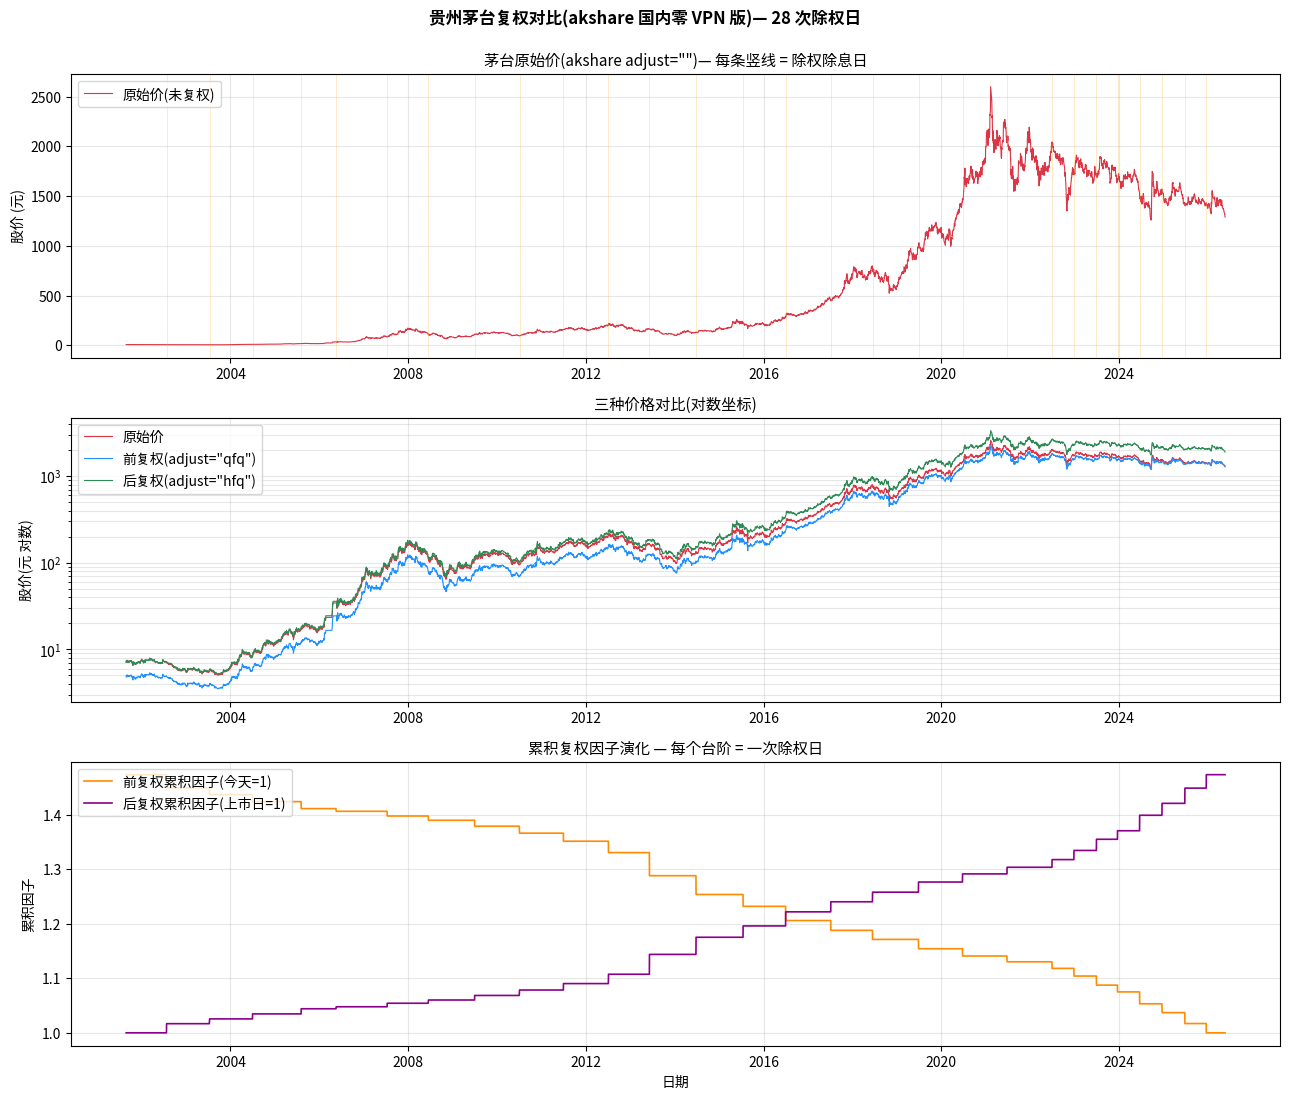

In [3]:
# day_027_adjustments_cn.py — 雅虎金融(yfinance)+ 本地 CSV 回退
# 雅虎金融的 Close = 原始价(未复权) Adj Close = 前复权(向前调整,今天=raw)
# 后复权由前复权反推:hfq = 前复权 × (上市日原始价 / 上市日前复权)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SYMBOL = '600519.SS'  # 贵州茅台,雅虎金融上海代码
START = '2001-08-27'  # 茅台 IPO 日

# CSV 路径自适应 — notebook 在 out/notebook/cn/ 时走 ../data/  从仓库根跑则走 out/notebook/data/
CSV_PATH = next((p for p in [Path('../data/D027_data.csv'), Path('out/notebook/data/D027_data.csv')] if p.parent.is_dir()), Path('../data/D027_data.csv'))

def fetch_via_yfinance():
    """联网拉雅虎金融,顺手缓存到本地 CSV 给下次离线用。"""
    import yfinance as yf
    print(f'尝试从雅虎金融拉取 {SYMBOL} ...')
    df = yf.download(SYMBOL, start=START, auto_adjust=False, progress=False, threads=False)
    if df is None or df.empty:
        raise RuntimeError('yfinance 返回空数据,可能被限速或网络不通')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    out = pd.DataFrame({'原始价': df['Close'].astype(float), '前复权': df['Adj Close'].astype(float)})
    out['后复权'] = out['前复权'] * (out['原始价'].iloc[0] / out['前复权'].iloc[0])
    out.index.name = '日期'
    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(CSV_PATH, encoding='utf-8-sig')
    print(f'✓ 雅虎金融拉到 {len(out)} 行,顺手缓存到 {CSV_PATH}')
    return out

def load_from_csv():
    if not CSV_PATH.exists():
        raise FileNotFoundError(f'本地 CSV 不存在 {CSV_PATH},请先联网跑 python tools/fetch_lesson_data.py 27')
    df = pd.read_csv(CSV_PATH, index_col='日期', parse_dates=True)
    print(f'✓ 从本地 CSV 加载 {len(df)} 行 ({df.index[0].date()} → {df.index[-1].date()})')
    return df

# ============ 1. 拉数据:优先雅虎金融,失败回退本地 CSV ============
try:
    data = fetch_via_yfinance()
except Exception as e:
    print(f'⚠ 雅虎金融拉取失败({type(e).__name__}): {e}')
    print('   回退本地 CSV ...')
    data = load_from_csv()

# 拆三个 DataFrame,接口跟原 akshare 版一致(raw/qfq/hfq 各自一列 收盘)
raw = pd.DataFrame({'收盘': data['原始价']})
qfq = pd.DataFrame({'收盘': data['前复权']})
hfq = pd.DataFrame({'收盘': data['后复权']})

# ============ 2. 输出关键统计 ============
print(f'=== 茅台 {raw.index[0].date()} → {raw.index[-1].date()} 三种数据对比 ===')
print(f'原始价  起 {raw["收盘"].iloc[0]:>10.2f} 终 {raw["收盘"].iloc[-1]:>10.2f}  倍数 {raw["收盘"].iloc[-1]/raw["收盘"].iloc[0]:>7.2f}')
print(f'前复权  起 {qfq["收盘"].iloc[0]:>10.2f} 终 {qfq["收盘"].iloc[-1]:>10.2f}  倍数 {qfq["收盘"].iloc[-1]/qfq["收盘"].iloc[0]:>7.2f}')
print(f'后复权  起 {hfq["收盘"].iloc[0]:>10.2f} 终 {hfq["收盘"].iloc[-1]:>10.2f}  倍数 {hfq["收盘"].iloc[-1]/hfq["收盘"].iloc[0]:>7.2f}')

# ============ 3. 手算复权因子 — 从原始价和前复权价反推 ============
# 关键 — 前复权因子 = 原始价 / 前复权价(今天的因子 = 1)
raw['close_qfq'] = qfq['收盘'].reindex(raw.index)
raw['fwd_cum'] = raw['收盘'] / raw['close_qfq']
raw['close_hfq'] = hfq['收盘'].reindex(raw.index)
raw['bwd_cum'] = raw['close_hfq'] / raw['收盘']

print(f'\n=== 累积复权因子 ===')
print(f'前复权因子(今天)= {raw["fwd_cum"].iloc[-1]:.4f} (应该接近 1)')
print(f'前复权因子(上市日)= {raw["fwd_cum"].iloc[0]:.4f} (历史价缩到原始价的多少分之一)')
print(f'后复权因子(今天)= {raw["bwd_cum"].iloc[-1]:.4f} (今天价格被放大多少倍)')

# ============ 4. 找出所有除权日(累积因子台阶变化的日期)============
raw['fwd_diff'] = raw['fwd_cum'].diff().abs()
events = raw[raw['fwd_diff'] > 0.001]  # 因子变化超过 0.001 视为除权日
print(f'\n检测到 {len(events)} 次除权除息日(累积因子跳变)')
print('前 5 次除权日 + 累积因子:')
print(events[['收盘', 'fwd_cum', 'bwd_cum']].head())

# ============ 5. 画图 ============
fig, axes = plt.subplots(3, 1, figsize=(13, 11))

axes[0].plot(raw.index, raw['收盘'], color='#dc3545', linewidth=0.8, label='原始价(未复权)')
for ex_date in events.index:
    axes[0].axvline(ex_date, color='orange', alpha=0.3, linewidth=0.5)
axes[0].set_title('茅台原始价(akshare adjust="")— 每条竖线 = 除权除息日', fontsize=11)
axes[0].set_ylabel('股价 (元)'); axes[0].grid(alpha=0.3); axes[0].legend(loc='upper left')

axes[1].semilogy(raw.index, raw['收盘'], color='#dc3545', linewidth=0.8, label='原始价')
axes[1].semilogy(qfq.index, qfq['收盘'], color='#1e90ff', linewidth=0.8, label='前复权(adjust="qfq")')
axes[1].semilogy(hfq.index, hfq['收盘'], color='#2e8b57', linewidth=0.8, label='后复权(adjust="hfq")')
axes[1].set_title('三种价格对比(对数坐标)', fontsize=11)
axes[1].set_ylabel('股价(元 对数)'); axes[1].grid(alpha=0.3, which='both'); axes[1].legend(loc='upper left')

axes[2].plot(raw.index, raw['fwd_cum'], color='#ff8c00', linewidth=1.2, label='前复权累积因子(今天=1)')
axes[2].plot(raw.index, raw['bwd_cum'], color='#8b008b', linewidth=1.2, label='后复权累积因子(上市日=1)')
axes[2].set_title('累积复权因子演化 — 每个台阶 = 一次除权日', fontsize=11)
axes[2].set_ylabel('累积因子'); axes[2].set_xlabel('日期')
axes[2].grid(alpha=0.3); axes[2].legend(loc='upper left')

plt.suptitle(f'贵州茅台复权对比(akshare 国内零 VPN 版)— {len(events)} 次除权日',
             fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('chart_01.png', dpi=120, bbox_inches='tight')
print('图已保存 chart_01.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| A 股 2001-08-27 | 贵州茅台 600519 | 茅台2001 年8 月在上交所挂牌上市,开盘价34.51元。二十多年里送过几次股、派过十几次现金分红。原始价今天看大概1500 块,看起来涨了四十多倍。但所有分红送股加回去后真实回报超过300 倍,后复权数据今天显示在11000 块附近。这是 A 股市场复权处理影响最戏剧化的经典例子,几乎所有量化教程都拿茅台举例。 |
| 美股 2020-08-31 | 苹果 AAPL | 苹果2020 年8 月做了一次四比一拆股,每股股价从前一天收盘五百多块跳到当天开盘一百二十多块。如果你看不复权的苹果数据画长期走势,会在那一天看到一个高高的悬崖。前复权数据下,2020 年8 月之前所有历史价格都被压低到原来的四分之一,曲线变得平滑。这是美股最有名的近期拆股事件,跟茅台一对照,你就能看清同样的复权逻辑在 A 股美股完全通用。 |
| 美股历史 | 苹果 AAPL 多次拆股 | 苹果从上市到今天总共拆过五次股,分别在 1987 年(2:1)/2000 年(2:1)/2005 年(2:1)/2014 年(7:1)/2020 年(4:1)。累积拆股比例是二乘二乘二乘七乘四等于224 倍。如果你看不复权的苹果数据,会看到从上市那个几块钱的发行价到今天接近两百块,看似涨了几十倍。实际后复权下来苹果累积回报是几千倍。这就是为什么科技股的长期收益数字必须用复权数据看,不复权会严重低估真实回报。 |
| 港股长期 | 腾讯控股 0700 | 腾讯2004 年6 月上市,2014 年做过一次五比一拆股。如果不复权,你看到的腾讯历史价格在2014 年那天会从五百多块突然跳到一百多块,跟茅台一样会污染均线策略。腾讯还每年派现金分红,虽然分红率不高但20 年累积起来也是几十块每股的差距。港股散户经常忽略这件事,以为只有送股影响,实际现金分红同样要在复权数据里调整。 |
| A 股长期 | 招商银行 600036 | 招行从2002 年上市到今天派过二十多次现金分红,累积每股分红超过20 块。如果不复权,你看到招行从上市的几块钱涨到今天三十多块,涨幅大概10 倍。后复权数据下,招行真实回报接近50 倍。所以那种『大盘股不需要复权』的说法是错的 — 任何派过现金分红的票,长期回报都会被严重低估,银行股、白酒股、消费股这些高分红行业差距尤其大。 |


## 常见坑

### ⚠ 01. 直接用不复权数据做回测

这是最常见的初学者错误。均线策略、动量策略、回归策略全部会被除权日跳变污染。看到回测曲线在某个日期突然垂直跌一截,十有89是没复权。**正确做法**:回测前先画一张原始价和复权价的对比图,看到有跳点立刻切换到复权数据。

### ⚠ 02. 前复权后复权混用

比如你用前复权的茅台价格算了一个均线信号,但你拿不复权的成交价当回测成交假设,这两套价格不对齐,回测收益就是错的。**正确做法**:整套回测系统从信号生成到成交价用同一种数据,代码里用不同的变量名区分,比如 close_qfq、close_hfq、close_raw。

### ⚠ 03. 把前复权数据当永久参考

今年又分红一次,所有历史价格都要变一次。如果你的回测代码缓存了去年的前复权数据,今年再跑就跟实时数据对不上。**正确做法**:做永久参考用后复权数据,或者保存原始价加上完整的分红事件表,需要时随时重算前复权。

### ⚠ 04. 忘了港股美股也要复权

很多散户以为只有 A 股有送股分红。实际美股苹果分过五次股,港股腾讯也送过股,所有有现金分红的票都要复权。**正确做法**:接入任何一个市场的数据,第一件事查它的默认复权设置,以及怎么显式切换三种数据。

### ⚠ 05. 把通胀和复权搞混

复权只调整公司事件(分红、送股、拆股、配股),不调整通胀。1980 年的工资跟今天比要算通胀,但2001 年茅台跟今天比只算复权就够了。**正确做法**:复权处理只针对发行方公司的事件,通胀调整另算,两件事不要混。

### ⚠ 06. 海外工具和国内工具默认设置不一样

海外那个常用工具默认是自动复权过的价(auto_adjust=True),要看原始价必须显式关掉。国内常用的拉数据工具默认就是前复权(adjust='qfq'),要看原始价必须显式指定 adjust 等于空字符串。**正确做法**:换数据源第一件事看默认 adjust 参数是什么,不要假设一致。

## 实战 SOP · 复权处理实战 SOP

1. 做股票回测必须用复权后的价格,从来没有例外 — 不复权就是裸奔
2. 看趋势看技术面用前复权,算长期累计收益用后复权,这两个口诀刻在脑子里
3. 接入任何一个数据源第一件事查默认 adjust 参数,海外工具默认自动复权 / 国内工具默认前复权
4. 前复权数据每次新分红都会变,不能用作永久参考 — 要永久参考用后复权
5. 看到回测曲线有突然垂直跳水,先看那一天有没有除权除息事件,十有89是没复权
6. 整套回测系统从信号生成到成交价用同一种数据 — 代码里用不同变量名区分三种价格
7. 跨市场策略每个市场单独测一遍复权设置 — A 股 / 港股 / 美股 / 期货市场复权规则有差异

> 把这段打印贴在你电脑边。

## 总结 · 你应该带走的

2. 除权除息那天股价会突然下跳一截,跳幅跟分红或送股的比例完全对得上 — 总市值不变只是切片更多
3. 前复权 = 把过去价格按今天单位换算,今天价格不变,曲线平滑符合直觉 — 看趋势看技术面用
4. 后复权 = 把今天价格按历史单位换算,过去价格不变,长期回报全包含 — 算收益做归因用
5. 复权方式只影响绝对价格数字,不影响百分比收益 — 但不复权会被除权日假跳点污染百分比
6. 复权因子 = 所有除权日调整系数的累乘,每日因子 = 前一天收盘价 / 除权后参考价
7. 累乘方向决定前复权后复权:从今天往回累乘 = 前复权 / 从过去往今天累乘 = 后复权
8. 茅台20 年原始价40 倍 vs 后复权三百多倍 — 不复权严重低估真实长期回报
9. 海外那个常用工具默认是自动复权,国内常用的拉数据工具默认是前复权 — 用任何源前先查默认

## 自测题

**Q1.** 除权除息那天股价突然下跳,是市场跌了吗?为什么?(提示:总市值变化)  答:不是市场跌,是规则规定的。送股是股数变多每股价格按比例降,派现金是公司账上钱减少每股价格相应降。两种情况你的账户总市值都没变,只是单价和股数换算了一下。

**Q2.** 看 K 线技术面应该用哪种复权?算长期年化收益应该用哪种?(提示:今天还是历史不变)  答:看 K 线技术面用前复权(今天价不变曲线平滑符合直觉)。算长期年化收益用后复权(过去价不变今天价格按累计因子放大体现真实回报)。

**Q3.** 茅台2010 年除权调整系数1.5,2015 年1.2,2020 年1.1。2005 年的某天原始价100 块,在今天的前复权视角下是多少?(提示:从今天往回累乘)  答:前复权累积因子 = 1.1乘1.2乘1.5 = 1.98。2005 年那100 块原始价除以1.98 = 大约50.5 块。

**Q4.** 为什么前复权数据每次新分红都会变?这对回测有什么影响?(提示:基准是哪天)  答:前复权基准是今天价格不变,每次新分红送股都要把所有历史价格再次调整一遍。这导致缓存去年的前复权数据跟今年实时数据对不上,所以前复权不能用作永久参考,要做永久参考必须用后复权。

**Q5.** 你用前复权数据画的均线信号,但成交价用了原始价。回测结果会怎样?(提示:同一时点两套价格)  答:回测错误。前复权和原始价在除权日附近的数字差异巨大,信号触发时点对应的回测成交价跟当时市场真实价不一致,导致回测年化虚高或虚低。正确做法是整套回测系统从信号到成交用同一套价格。

把答案写下来,3 天后再回看。

## 下一节预告

**Day 028 · 行情频率与场景** (Frequency Tradeoffs)

第28 天讲行情频率,日线、分钟线、Tick 数据这3 档怎么选。我们搞定了数据来源和复权处理,接下来要看不同时间精度的数据各自适合做什么。日线适合做长期持有策略,分钟线适合做日内择时,Tick 数据是高频做市的命脉。三种数据存储成本差几个数量级,选错档位你要么浪费钱要么做不出策略。

## 推荐阅读

- Bodie, Kane, Marcus《Investments》(2018 第 11 版, McGraw-Hill)— 投资学经典教科书,股息和股票分割章节讲清楚复权的会计基础
- Harris《Trading and Exchanges》(2003 Oxford)— 市场微结构教科书,关于公司事件如何影响价格序列的工程视角
- Schwert《Stock Market Volatility and the Crash of 87》(Review of Financial Studies 1990)— 实证文献里反复强调用复权后的收益率计算波动率,不复权数据会严重低估
- 李迅雷《价值投资在中国》(2020 中信出版社)— 国内白马股长期回报实证,茅台、招行、平安等案例都用复权数据测算
- Python 工具栈:yfinance(海外股票 auto_adjust 参数控制三种数据)/ akshare(国内 stock_zh_a_hist 用 adjust 参数控制)/ Tushare Pro(国内付费数据源,复权字段更完整)/ pandas-datareader(老牌通用接口) — 散户首选 yfinance + akshare 双源对比